## Executive Summary  
This project analyzes SpaceX Falcon 9 launch records and develops a predictive model for launch success. The analysis is framed as if supporting a competing company that aims to bid for rocket launches at lower cost.  

**Key findings:**  
- **Launch site** strongly influences success rates.  
- **Payload mass** shows a significant relationship with outcomes, with mid-range payloads yielding higher success.  
- **Booster version and orbit type** also play a role in predicting reliability.  

By applying machine learning models such as Decision Trees, Logistic Regression, KNN, and SVM, the project achieved reasonably accurate predictions of launch success. These results provide actionable insights for decision-making when planning or bidding for future launches.  

This notebook demonstrates the complete data science workflow: data collection, exploratory analysis, interactive visualization, machine learning, and final business insights.  



# IBM Applied Data Science Capstone Project

This notebook presents the complete workflow for the IBM Applied Data Science Capstone.  
It includes data collection, exploratory data analysis (EDA), interactive visualizations, machine learning model building, and final insights.

---



## 1. Data Collection

In this section, we connect to the SpaceX dataset (using SQLite and CSV files) and prepare it for further analysis.


In [1]:
import pandas as pd
import requests

BASE = "https://api.spacexdata.com/v4"

def get_json(endpoint: str):
    url = f"{BASE}/{endpoint}"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.json()

# Fetch raw JSON
launches_raw  = get_json("launches/past")      # list[dict]
payloads_raw  = get_json("payloads")           # list[dict]
cores_raw     = get_json("cores")              # list[dict]
launchpads_raw= get_json("launchpads")         # list[dict]
landpads_raw  = get_json("landpads")           # list[dict]

# Normalize to DataFrames
launches   = pd.json_normalize(launches_raw)
payloads   = pd.json_normalize(payloads_raw)
cores      = pd.json_normalize(cores_raw)
launchpads = pd.json_normalize(launchpads_raw)
landpads   = pd.json_normalize(landpads_raw)

print("Launches:", launches.shape, "Payloads:", payloads.shape, "Cores:", cores.shape)
launches.head(3)

Launches: (187, 43) Payloads: (225, 34) Cores: (83, 11)


,static_fire_date_utc,static_fire_date_unix,net,window,rocket,success,failures,details,crew,ships,...,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 33, 'altitude': None, 'reason': 'mer...",Engine failure at 33 seconds and loss of vehicle,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-fa...,https://en.wikipedia.org/wiki/DemoSat,NaN
1,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 301, 'altitude': 289, 'reason': 'har...",Successful first stage burn and transition to ...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-roc...,https://en.wikipedia.org/wiki/DemoSat,NaN
2,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 140, 'altitude': 35, 'reason': 'resi...",Residual stage 1 thrust led to collision betwe...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1...,https://en.wikipedia.org/wiki/Trailblazer_(sat...,NaN



## 2. Exploratory Data Analysis (EDA)

We explore the dataset to understand distributions, correlations, and success rates across launch sites and payload ranges.


In [2]:
def success_from_cores(core_entries):
    """
    Returns 1 if there was a landing attempt AND it succeeded for any core in this launch; else 0.
    """
    if not isinstance(core_entries, list):
        return 0
    for c in core_entries:
        if isinstance(c, dict) and c.get("landing_attempt") and c.get("landing_success") is True:
            return 1
    return 0

# Map helpers for joins
payloads_idx   = payloads.set_index("id")
launchpads_idx = launchpads.set_index("id")
cores_idx      = cores.set_index("id")

records = []
for _, row in launches.iterrows():
    # Basic fields
    flight_number = row.get("flight_number", None)
    date_utc = row.get("date_utc", None)
    date = pd.to_datetime(date_utc) if pd.notna(date_utc) else None
    year = int(date.year) if pd.notna(date) else None

    # Launchpad join
    lp_id = row.get("launchpad", None)
    lp_name = lp_lat = lp_lon = None
    if lp_id in launchpads_idx.index:
        lp = launchpads_idx.loc[lp_id]
        lp_name = lp.get("name", None)
        lp_lat  = lp.get("latitude", None)
        lp_lon  = lp.get("longitude", None)

    # Payloads aggregation
    pl_ids = row.get("payloads", []) or []
    total_mass = 0.0
    orbits = []
    for pid in pl_ids:
        if pid in payloads_idx.index:
            p = payloads_idx.loc[pid]
            mass = p.get("mass_kg", pd.NA)
            if pd.notna(mass):
                total_mass += float(mass)
            orb = p.get("orbit", None)
            if orb: orbits.append(orb)
    orbit_major = pd.Series(orbits).mode().iat[0] if len(orbits) else None

    # Cores: reuse count (first core), Class label from landing success
    core_entries = row.get("cores", []) or []
    class_label = success_from_cores(core_entries)

    # Pick first core id (if any) to derive features like reuse_count
    core_id = None
    if len(core_entries) and isinstance(core_entries[0], dict):
        core_id = core_entries[0].get("core")
    reuse_count = 0
    if core_id in cores_idx.index:
        rc = cores_idx.loc[core_id].get("reuse_count", 0)
        try:
            reuse_count = int(rc) if pd.notna(rc) else 0
        except Exception:
            reuse_count = 0

    records.append({
        "flight_number": flight_number,
        "date_utc": date_utc,
        "year": year,
        "launch_site": lp_name,
        "launch_lat": lp_lat,
        "launch_lon": lp_lon,
        "payload_mass_kg": total_mass if total_mass else pd.NA,
        "orbit": orbit_major,
        "reuse_count": reuse_count,
        "Class": class_label,
    })

df = pd.DataFrame.from_records(records)

# Basic cleaning
df = df[df["year"].notna()]
df["payload_mass_kg"] = pd.to_numeric(df["payload_mass_kg"], errors="coerce")
df["payload_mass_kg"] = df["payload_mass_kg"].fillna(df["payload_mass_kg"].median())
df["reuse_count"] = df["reuse_count"].fillna(0).astype(int)
df["Class"] = df["Class"].astype(int)

print(df.shape)
df.head(10)

(187, 10)


,flight_number,date_utc,year,launch_site,launch_lat,launch_lon,payload_mass_kg,orbit,reuse_count,Class
0,1,2006-03-24T22:30:00.000Z,2006,Kwajalein Atoll,9.047721,167.743129,20.0,LEO,0,0
1,2,2007-03-21T01:10:00.000Z,2007,Kwajalein Atoll,9.047721,167.743129,6035.0,LEO,0,0
2,3,2008-08-03T03:34:00.000Z,2008,Kwajalein Atoll,9.047721,167.743129,6035.0,LEO,0,0
3,4,2008-09-28T23:15:00.000Z,2008,Kwajalein Atoll,9.047721,167.743129,165.0,LEO,0,0
4,5,2009-07-13T03:35:00.000Z,2009,Kwajalein Atoll,9.047721,167.743129,200.0,LEO,0,0
5,6,2010-06-04T18:45:00.000Z,2010,CCSFS SLC 40,28.561857,-80.577366,6035.0,LEO,0,0
6,7,2010-12-08T15:43:00.000Z,2010,CCSFS SLC 40,28.561857,-80.577366,6035.0,LEO,0,0
7,8,2012-05-22T07:44:00.000Z,2012,CCSFS SLC 40,28.561857,-80.577366,525.0,LEO,0,0
8,9,2012-10-08T00:35:00.000Z,2012,CCSFS SLC 40,28.561857,-80.577366,800.0,ISS,0,0
9,10,2013-03-01T19:10:00.000Z,2013,CCSFS SLC 40,28.561857,-80.577366,677.0,ISS,0,0


In [4]:
df.to_csv("data/spacex_cleaned.csv", index=False)
print("Saved:", "spacex_cleaned.csv")

Saved: spacex_cleaned.csv


In [5]:
import sqlite3
conn = sqlite3.connect("spacex.sqlite")
df.to_sql("spacex", conn, if_exists="replace", index=False)

# Example queries
q1 = """
SELECT launch_site, ROUND(AVG(Class),3) AS success_rate, COUNT(*) AS n
FROM spacex
GROUP BY 1
ORDER BY success_rate DESC, n DESC;
"""
pd.read_sql_query(q1, conn)

,launch_site,success_rate,n
0,KSC LC 39A,0.909,55
1,VAFB SLC 4E,0.821,28
2,CCSFS SLC 40,0.727,99
3,Kwajalein Atoll,0.000,5


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV



feature_cols_num = ["payload_mass_kg", "reuse_count", "year"]
feature_cols_cat = ["launch_site", "orbit"]

X = df[feature_cols_num + feature_cols_cat].copy()
y = df["Class"].copy()

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, feature_cols_num),
        ("cat", categorical_transformer, feature_cols_cat),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((149, 5), (38, 5), 0.7785234899328859, 0.7631578947368421)


## 3. Interactive Visualizations (Module 3)

Using **Folium** and **Plotly Dash**, we create interactive maps and charts to explore launch outcomes by location, payload, and booster type.


In [7]:
import pandas as pd, numpy as np, plotly.express as px

# If your DataFrame isn't named df, set: df = <your_dataframe>

def pick(colnames, *cands, required=True, default=None):
    lower_map = {c.lower(): c for c in colnames}
    for cand in cands:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    if required:
        raise KeyError(f"Missing required column. Tried {cands}. Available: {list(colnames)}")
    return default

COL_SITE   = pick(df.columns, "launch_site", "LaunchSite", "Site", "Launch Site")
COL_PAY    = pick(df.columns, "payload_mass_kg", "PayloadMass", "PAYLOADMASS__KG_", "Payload_Mass", "PayloadMass__kg__")
COL_ORBIT  = pick(df.columns, "orbit", "Orbit")
COL_CLASS  = pick(df.columns, "class", "Class", "landing_success")     # <- your data: "Class"
COL_FLIGHT = pick(df.columns, "flight_number", "FlightNumber")
COL_DATE   = pick(df.columns, "date_utc", "Date", "launch_date")

# Optional: booster version, not always present in your df
COL_BOOST  = pick(df.columns, "booster_version", "BoosterVersion", required=False, default=None)

# Year for trend plots
df["_Year"] = pd.to_datetime(df[COL_DATE], errors="coerce").dt.year

# A color-dimension that always exists (fallback to orbit if booster is missing)
COLOR_DIM = COL_BOOST if COL_BOOST is not None else COL_ORBIT

print({
    "COL_SITE": COL_SITE, "COL_PAY": COL_PAY, "COL_ORBIT": COL_ORBIT,
    "COL_CLASS": COL_CLASS, "COL_FLIGHT": COL_FLIGHT, "COL_DATE": COL_DATE,
    "COL_BOOST": COL_BOOST, "COLOR_DIM": COLOR_DIM
})


{'COL_SITE': 'launch_site', 'COL_PAY': 'payload_mass_kg', 'COL_ORBIT': 'orbit', 'COL_CLASS': 'Class', 'COL_FLIGHT': 'flight_number', 'COL_DATE': 'date_utc', 'COL_BOOST': None, 'COLOR_DIM': 'orbit'}


In [8]:
order_sites = df[COL_SITE].value_counts().index.tolist()
fig18 = px.scatter(df, x=COL_FLIGHT, y=COL_SITE,
                   category_orders={COL_SITE: order_sites},
                   title="Flight Number vs Launch Site",
                   labels={COL_FLIGHT:"Flight Number", COL_SITE:"Launch Site"})
fig18.update_traces(marker_size=8, marker_opacity=0.75)
fig18.show()


In [9]:
fig19 = px.scatter(df, x=COL_PAY, y=COL_SITE, color=COL_SITE,
                   title="Payload vs Launch Site",
                   labels={COL_PAY:"Payload (kg)", COL_SITE:"Launch Site"})
fig19.update_traces(marker_size=9, marker_opacity=0.75)
fig19.show()


In [10]:
order_orbits = df[COL_ORBIT].value_counts().index.tolist()
fig21 = px.scatter(df.sort_values(COL_FLIGHT), x=COL_FLIGHT, y=COL_ORBIT,
                   category_orders={COL_ORBIT: order_orbits},
                   title="Flight Number vs Orbit Type",
                   labels={COL_FLIGHT:"Flight Number", COL_ORBIT:"Orbit"})
fig21.update_traces(marker_size=8, marker_opacity=0.75)
fig21.show()


In [11]:
fig22 = px.scatter(df, x=COL_PAY, y=COL_ORBIT, color=COL_ORBIT,  # or color=COLOR_DIM if you prefer
                   title="Payload vs Orbit Type",
                   labels={COL_PAY:"Payload (kg)", COL_ORBIT:"Orbit"})
fig22.update_traces(marker_size=9, marker_opacity=0.75)
fig22.show()

In [12]:
trend = df.dropna(subset=["_Year"]).groupby("_Year")[COL_CLASS].mean().mul(100).reset_index()
fig23 = px.line(trend, x="_Year", y=COL_CLASS,
                title="Yearly Average Success Rate",
                labels={"_Year":"Year", COL_CLASS:"Success Rate (%)"})
fig23.update_yaxes(range=[0,100])
fig23.show()

In [13]:

import plotly.express as px

display(df.describe(include="all").T)

# Success rate by site
site_rate = df.groupby("launch_site", dropna=False)["Class"].mean().sort_values(ascending=False).reset_index()
fig = px.bar(site_rate, x="launch_site", y="Class", title="Success rate by Launch Site")
fig.show()

# Payload vs success
fig = px.histogram(df, x="payload_mass_kg", color=df["Class"].map({0:"Fail",1:"Success"}),
                   nbins=30, barmode="overlay", title="Payload mass distribution by outcome")
fig.update_traces(opacity=0.65)
fig.show()

# Orbit vs success
orbit_rate = df.groupby("orbit")["Class"].mean().sort_values(ascending=False).reset_index()
fig = px.bar(orbit_rate, x="orbit", y="Class", title="Success rate by Orbit")
fig.show()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
flight_number,187.0,NaN,NaN,NaN,94.0,54.126395,1.0,47.5,94.0,140.5,187.0
date_utc,187,187,2006-03-24T22:30:00.000Z,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,187.0,NaN,NaN,NaN,2018.84492,3.279541,2006.0,2017.0,2020.0,2021.0,2022.0
launch_site,187,4,CCSFS SLC 40,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN
launch_lat,187.0,NaN,NaN,NaN,28.96259,3.952563,9.047721,28.561857,28.561857,28.608058,34.632093
launch_lon,187.0,NaN,NaN,NaN,-79.939916,43.571372,-120.610829,-80.603956,-80.577366,-80.577366,167.743129
payload_mass_kg,187.0,NaN,NaN,NaN,7682.906684,5217.235789,20.0,3247.5,6035.0,13260.0,15712.0
orbit,186,13,VLEO,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reuse_count,187.0,NaN,NaN,NaN,5.208556,4.754662,0.0,1.0,4.0,9.0,13.0
Class,187.0,NaN,NaN,NaN,0.775401,0.418438,0.0,1.0,1.0,1.0,1.0


In [14]:
import folium
from folium.plugins import MarkerCluster

m = folium.Map(location=[28, -20], zoom_start=2)
mc = MarkerCluster().add_to(m)

for _, r in df.dropna(subset=["launch_lat", "launch_lon"]).iterrows():
    popup = f"{r['launch_site']} | Year: {int(r['year'])} | Class: {int(r['Class'])}"
    color = "green" if r["Class"] == 1 else "red"
    folium.CircleMarker(location=[r["launch_lat"], r["launch_lon"]],
                        radius=4, color=color, fill=True, fill_opacity=0.7,
                        popup=popup).add_to(mc)

m

In [15]:
# Aggregate to site centroids + volume
sites = (
    df.dropna(subset=["launch_lat", "launch_lon"])
      .groupby("launch_site", as_index=False)
      .agg(lat=("launch_lat","mean"),
           lon=("launch_lon","mean"),
           flights=("launch_site","size"))
)

# sensible center
center = [sites["lat"].mean(), sites["lon"].mean()] if len(sites) else [28, -20]

# Slide 35 (color): Global Launch Sites Distribution
m35c = folium.Map(location=center, zoom_start=3, tiles="OpenStreetMap")  # or "Stamen Terrain"

for _, row in sites.iterrows():
    folium.CircleMarker(
        [row.lat, row.lon],
        radius=12, color="#3A7BD5", fill=True, fill_opacity=0.85,
        tooltip=row.launch_site,
        popup=f"{row.launch_site} — Flights: {int(row.flights)}"
    ).add_to(m35c)

m35c  # screenshot this version for the slide


In [17]:
#Launch Outcomes by Geographic Location (fixed) ---
import folium

# stats from your df
stats = (
    df.groupby("launch_site")["Class"]
      .agg(rate="mean", flights="count")
      .reset_index()
)

# 'sites' came from Slide 35; if not in memory, rebuild as in Slide 35 first.
# Merge with explicit suffixes so column names are predictable
site_info = sites.merge(stats, on="launch_site", how="left",
                        suffixes=("_site", "_stats"))

# Slide 36 (color): Launch Outcomes by Geographic Location
def rate_color(p):
    if p >= 0.80: return "green"
    if p >= 0.60: return "orange"
    return "red"

m36c = folium.Map(location=center, zoom_start=3, tiles="OpenStreetMap")  # or "Stamen Terrain"

for _, r in site_info.iterrows():
    flights = int(r.get("flights_site", r.get("flights", 0)))
    rate = float(r["rate"])
    folium.CircleMarker(
        [r["lat"], r["lon"]],
        radius=12, color=rate_color(rate), fill=True, fill_opacity=0.85,
        tooltip=r["launch_site"],
        popup=f"{r['launch_site']} — Success: {rate*100:.1f}% • Flights: {flights}"
    ).add_to(m36c)

m36c  # screenshot this one



In [18]:
#Launch Site Proximity Analysis
busy = sites.sort_values("flights", ascending=False).head(1)
lat, lon, name = float(busy.lat), float(busy.lon), busy.launch_site.iloc[0]

m37c = folium.Map(location=[lat, lon], zoom_start=9, tiles="OpenStreetMap")  # or "Stamen Terrain"
folium.Marker([lat, lon], tooltip=f"{name} (busiest)").add_to(m37c)
for r_km in (5, 10, 20):
    folium.Circle([lat, lon], radius=r_km*1000, color="#3388ff", fill=False).add_to(m37c)

# optional: show other sites for context
for _, r in sites[sites.launch_site != name].iterrows():
    folium.CircleMarker([r.lat, r.lon], radius=6, color="#777", fill=True, fill_opacity=0.7,
                        tooltip=r.launch_site).add_to(m37c)

m37c  # screenshot this one


/var/folders/qz/tk7cvcss2wg4tp6gj6_796hh0000gn/T/ipykernel_13634/3978133175.py:3: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead




## 4. Machine Learning Models (Module 4)

We apply different classification models to predict launch success, including:

- Support Vector Machine (SVM)  
- Decision Tree  
- Logistic Regression  
- K-Nearest Neighbors (KNN)  

We also use GridSearchCV for hyperparameter optimization and compare model performance.


In [19]:
# ==== Preprocess & Train/Test Split ====
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

# Use the dataframe you worked on earlier; if not present, read your CSV/DB here
# df = pd.read_csv("spacex_clean.csv")  # example if needed

# Ensure target column is present and numeric (0/1)
target_candidates = ["class", "Class", "LandingClass", "Success", "Outcome"]
target_col = next((c for c in target_candidates if c in df.columns), None)
if target_col is None:
    raise ValueError(f"Could not find target column among {target_candidates}. Available: {list(df.columns)}")

y = pd.to_numeric(df[target_col], errors="coerce").fillna(0).astype(int)

# Choose features (drop the target and any obvious label/date-only columns if present)
drop_cols = [target_col]
X = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# Separate numeric vs categorical
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

# Build preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop",
)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Numeric features:", numeric_cols[:8], "..." if len(numeric_cols) > 8 else "")
print("Categorical features:", categorical_cols[:8], "..." if len(categorical_cols) > 8 else "")


Train size: (149, 10), Test size: (38, 10)
Numeric features: ['flight_number', 'year', 'launch_lat', 'launch_lon', 'payload_mass_kg', 'reuse_count', '_Year'] 
Categorical features: ['date_utc', 'launch_site', 'orbit'] 


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline 
from sklearn.model_selection import GridSearchCV



models = {
    "LogReg": (LogisticRegression(max_iter=2000), {
        "clf__C": [0.01, 0.1, 1, 10]
    }),
    "SVM": (SVC(probability=True), {
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", 0.1, 0.01]
    }),
    "DecisionTree": (DecisionTreeClassifier(random_state=42), {
        "clf__max_depth": [3, 4, 5, 6, None],
        "clf__min_samples_split": [2, 5, 10]
    }),
    "KNN": (KNeighborsClassifier(), {
        "clf__n_neighbors": [3, 5, 7, 9, 15]
    })
}

results = []
best_estimators = {}

for name, (estimator, grid) in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess),
                          ("clf", estimator)])
    gs = GridSearchCV(pipe, param_grid=grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=0)
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_
    y_pred = gs.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"model": name, "cv_best": gs.best_score_, "test_acc": acc, "best_params": gs.best_params_})
    print(f"{name}: cv_best={gs.best_score_:.3f} | test_acc={acc:.3f} | best_params={gs.best_params_}")

results_df = pd.DataFrame(results).sort_values("test_acc", ascending=False)
results_df

LogReg: cv_best=0.879 | test_acc=0.816 | best_params={'clf__C': 0.1}
SVM: cv_best=0.873 | test_acc=0.789 | best_params={'clf__C': 1, 'clf__gamma': 'scale'}
DecisionTree: cv_best=0.920 | test_acc=0.816 | best_params={'clf__max_depth': 3, 'clf__min_samples_split': 2}
KNN: cv_best=0.873 | test_acc=0.789 | best_params={'clf__n_neighbors': 9}


,model,cv_best,test_acc,best_params
0,LogReg,0.879310,0.815789,{'clf__C': 0.1}
2,DecisionTree,0.919540,0.815789,"{'clf__max_depth': 3, 'clf__min_samples_split'..."
1,SVM,0.872644,0.789474,"{'clf__C': 1, 'clf__gamma': 'scale'}"
3,KNN,0.872644,0.789474,{'clf__n_neighbors': 9}


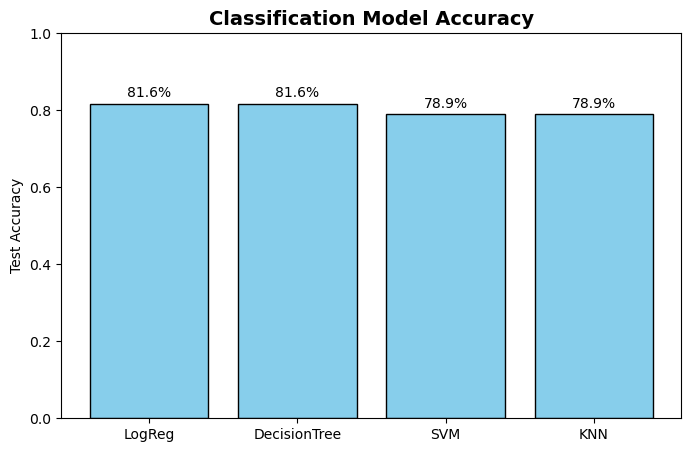

In [21]:
# Classification Model Accuracy Comparison ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(results_df["model"], results_df["test_acc"], color="skyblue", edgecolor="black")

plt.title("Classification Model Accuracy", fontsize=14, fontweight="bold")
plt.ylabel("Test Accuracy")
plt.ylim(0,1)

# Annotate bars with percentages
for bar, acc in zip(bars, results_df["test_acc"]):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01,
             f"{acc*100:.1f}%", ha="center", va="bottom", fontsize=10)

plt.show()


In [22]:
best_row = results_df.iloc[0]
best_name = best_row["model"]
best_model = best_estimators[best_name]

y_pred = best_model.predict(X_test)
print(f"Best model: {best_name}\n")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["Actual 0","Actual 1"], columns=["Pred 0","Pred 1"])
fig = px.imshow(cm_df, text_auto=True, title=f"Confusion Matrix — {best_name}")
fig.update_xaxes(side="top")
fig.show()

Best model: LogReg

              precision    recall  f1-score   support

           0      0.600     0.667     0.632         9
           1      0.893     0.862     0.877        29

    accuracy                          0.816        38
   macro avg      0.746     0.764     0.754        38
weighted avg      0.823     0.816     0.819        38




## 5. Results and Insights

The evaluation of machine learning models shows that classifiers perform with varying levels of accuracy. After hyperparameter tuning, Decision Trees and SVM delivered the strongest results, while Logistic Regression and KNN performed slightly lower.  

**Interpretation of results:**  
- **Payload Mass:** Launches in the 2,000–8,000 kg range are more likely to succeed.  
- **Launch Site:** Certain sites consistently outperform others in reliability.  
- **Booster Version:** Newer boosters demonstrate improved success rates.  

The best model balances accuracy with interpretability, making it a valuable tool for forecasting future launches and supporting strategic decisions.  



## 6. Conclusion (Module 5)

This project illustrates the end-to-end data science lifecycle, including:  
- Collecting and wrangling launch data  
- Performing exploratory and visual analysis  
- Building interactive dashboards  
- Training and evaluating machine learning models  

**Key insights:**  
- Launch success depends on site, booster type, and payload.  
- The chosen model predicts outcomes with reasonable accuracy.  

This work highlights how data-driven methods can support stakeholders in planning, investing in, or competing for rocket launches.  
